# Tarea Nº1 — Inteligencia Artificial 2026-1
## Universidad Diego Portales — Facultad de Ingeniería y Ciencias

**Estudiante:** Maximiliano (completar apellido)

**Declaración de uso de herramientas generativas:** Se utilizó un asistente de IA (Windsurf/Cascade) como apoyo en la generación de código base y estructura del notebook. Todo el análisis e interpretación de resultados fue realizado por el estudiante.

---

In [1]:
# Descomentar si es necesario:
# !pip install pgmpy hmmlearn pandas numpy matplotlib seaborn scikit-learn networkx

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch
from pgmpy.estimators import BIC, BDeu, K2
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling

from hmmlearn import hmm

np.random.seed(42)
sns.set_style('whitegrid')
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# PARTE 1 — Red Bayesiana (35 pts)

## 1.1 Carga y exploración del dataset

Se utiliza el dataset **Adult Census Income** de UCI Machine Learning Repository. Este dataset contiene **32.561 filas** y **15 columnas** con información demográfica y laboral de personas, donde la variable objetivo indica si el ingreso anual supera los 50 mil dólares.

**Justificación:** Cumple holgadamente con el requisito de ≥ 8.000 filas y ≥ 7 columnas útiles. Además, contiene una mezcla de variables categóricas y numéricas que lo hacen interesante para el análisis con Redes Bayesianas.

In [3]:
# ── 1.1 Carga del dataset Adult Census Income ──
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
             'marital_status', 'occupation', 'relationship', 'race', 'sex',
             'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df_adult = pd.read_csv('data/adult.data', header=None, names=col_names,
                       sep=r'\s*,\s*', engine='python', na_values='?')

print(f"Dimensiones del dataset: {df_adult.shape[0]} filas x {df_adult.shape[1]} columnas")
print(f"\nValores nulos por columna:")
print(df_adult.isnull().sum())
df_adult.head()

Dimensiones del dataset: 32561 filas x 15 columnas

Valores nulos por columna:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1.2 Preprocesamiento y selección de columnas

Para trabajar con Redes Bayesianas en pgmpy, necesitamos variables **discretas/categóricas**. Se realizan los siguientes pasos:

1. **Eliminar columnas poco útiles:** `fnlwgt` (peso de muestreo del censo, no tiene valor predictivo), `education_num` (redundante con `education`), `native_country` (demasiadas categorías, dificulta el aprendizaje).
2. **Eliminar filas con valores nulos.**
3. **Discretizar variables continuas** (`age`, `capital_gain`, `capital_loss`, `hours_per_week`) en rangos categóricos.

Columnas finales seleccionadas (≥ 7): `age_bin`, `workclass`, `education`, `marital_status`, `occupation`, `relationship`, `race`, `sex`, `capital_gain_bin`, `hours_bin`, `income`.

In [4]:
# ── 1.2 Preprocesamiento ──
# Eliminar filas con nulos
df_clean = df_adult.dropna().copy()
print(f"Filas después de eliminar nulos: {len(df_clean)}")

# Eliminar columnas poco útiles
df_clean = df_clean.drop(columns=['fnlwgt', 'education_num', 'native_country', 'capital_loss'])

# Discretizar variables continuas
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=[0, 25, 35, 50, 65, 100],
                             labels=['joven', 'adulto_joven', 'adulto', 'adulto_mayor', 'anciano'])

df_clean['capital_gain_bin'] = pd.cut(df_clean['capital_gain'],
                                      bins=[-1, 0, 5000, 100000],
                                      labels=['sin_ganancia', 'ganancia_baja', 'ganancia_alta'])

df_clean['hours_bin'] = pd.cut(df_clean['hours_per_week'],
                               bins=[0, 20, 40, 60, 100],
                               labels=['part_time', 'full_time', 'overtime', 'extreme'])

# Seleccionar las columnas finales para la Red Bayesiana
cols_bn = ['age_bin', 'workclass', 'education', 'marital_status', 'occupation',
           'relationship', 'race', 'sex', 'capital_gain_bin', 'hours_bin', 'income']

df_bn = df_clean[cols_bn].copy()

# Convertir todo a tipo categórico string
for c in df_bn.columns:
    df_bn[c] = df_bn[c].astype(str)

print(f"\nDataset final para Red Bayesiana: {df_bn.shape[0]} filas x {df_bn.shape[1]} columnas")
print(f"Columnas: {list(df_bn.columns)}")
df_bn.head()

Filas después de eliminar nulos: 30162

Dataset final para Red Bayesiana: 30162 filas x 11 columnas
Columnas: ['age_bin', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain_bin', 'hours_bin', 'income']


,age_bin,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain_bin,hours_bin,income
0,adulto,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,ganancia_baja,full_time,<=50K
1,adulto,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,sin_ganancia,part_time,<=50K
2,adulto,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,sin_ganancia,full_time,<=50K
3,adulto_mayor,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,sin_ganancia,full_time,<=50K
4,adulto_joven,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,sin_ganancia,full_time,<=50K


## 1.3 Aprendizaje de estructura — Método Hill-Climbing

### Explicación del método

**Hill-Climbing Search** es un algoritmo de búsqueda local voraz (*greedy*) para aprender la estructura de una Red Bayesiana:

1. Comienza con un grafo vacío (sin arcos) o una estructura inicial dada.
2. En cada iteración, evalúa todas las posibles operaciones locales: **agregar**, **eliminar** o **invertir** un arco.
3. Para cada operación candidata, calcula una **función de puntuación** (como BIC o BDeu) que mide qué tan bien se ajusta la estructura a los datos.
4. Selecciona la operación que **maximiza la mejora** en la puntuación y la aplica.
5. Repite hasta que ninguna operación mejore la puntuación (convergencia a un óptimo local).

**Ventaja:** Es eficiente computacionalmente, escala bien a datasets con muchas variables.
**Limitación:** Puede quedar atrapado en **óptimos locales**, es decir, la estructura encontrada no es necesariamente la mejor global.

In [5]:
# ── 1.3 Hill-Climbing Search ──
scoring_method = BIC(df_bn)

hc = HillClimbSearch(df_bn)
best_model_hc = hc.estimate(
    scoring_method=scoring_method,
    max_indegree=3,
    max_iter=500,
    show_progress=True
)

print("\nEstructura aprendida con Hill-Climbing:")
print(f"Arcos encontrados ({len(best_model_hc.edges())}):")
for edge in best_model_hc.edges():
    print(f"  {edge[0]} -> {edge[1]}")

  0%|                                                                                                                                                                                           | 0/500 [00:00<?, ?it/s]

  0%|▎                                                                                                                                                                                  | 1/500 [00:00<02:22,  3.50it/s]

  1%|█▊                                                                                                                                                                                 | 5/500 [00:00<00:34, 14.32it/s]

  2%|███▏                                                                                                                                                                               | 9/500 [00:00<00:24, 20.43it/s]

  3%|████▋                                                                                                                                                                             | 13/500 [00:00<00:19, 24.56it/s]

  3%|██████                                                                                                                                                                            | 17/500 [00:00<00:21, 22.34it/s]


Estructura aprendida con Hill-Climbing:
Arcos encontrados (17):
  age_bin -> income
  age_bin -> capital_gain_bin
  marital_status -> relationship
  marital_status -> age_bin
  occupation -> education
  occupation -> workclass
  relationship -> sex
  relationship -> income
  relationship -> hours_bin
  relationship -> race
  sex -> occupation
  hours_bin -> age_bin
  hours_bin -> occupation
  hours_bin -> sex
  hours_bin -> income
  income -> occupation
  income -> capital_gain_bin


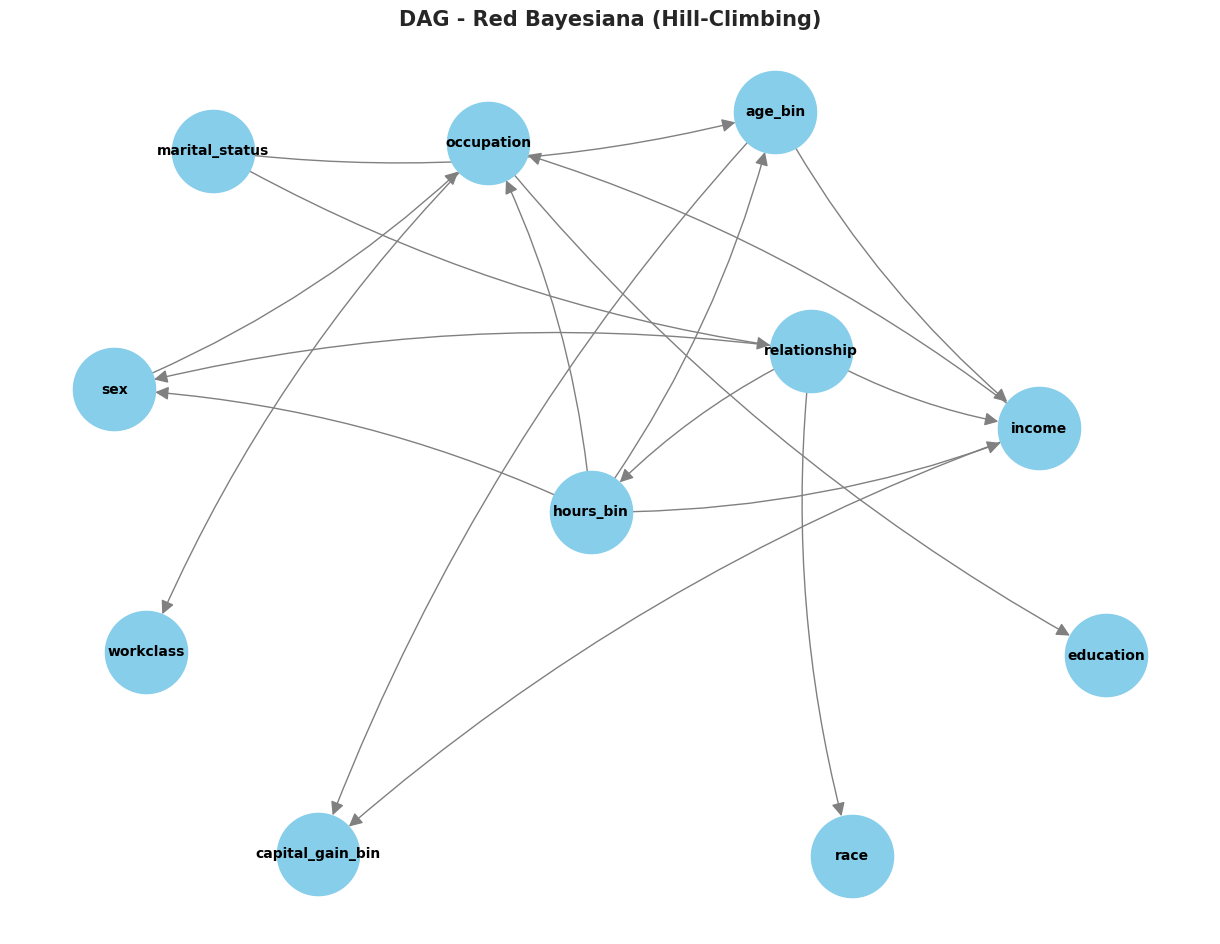

In [6]:
# ── Visualización del DAG (Hill-Climbing) ──
def plot_dag(edges, title):
    dag = nx.DiGraph(edges)
    plt.figure(figsize=(12, 9))
    pos = nx.spring_layout(dag, seed=42, k=2)
    nx.draw(dag, pos, with_labels=True, node_size=3500, node_color="#87CEEB",
            font_size=10, font_weight="bold", arrowsize=20, edge_color="gray",
            arrows=True, connectionstyle="arc3,rad=0.1")
    plt.title(title, size=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_dag(best_model_hc.edges(), "DAG - Red Bayesiana (Hill-Climbing)")

## 1.4 Aprendizaje de estructura — Búsqueda Exhaustiva

### Explicación del método

**Exhaustive Search** evalúa **todas las posibles estructuras DAG** y selecciona la que maximiza la función de puntuación. Es el método óptimo porque garantiza encontrar la mejor estructura global.

**Funcionamiento:**
1. Genera todas las combinaciones posibles de arcos entre las variables.
2. Filtra las que forman **DAGs válidos** (sin ciclos).
3. Calcula la puntuación (BIC, BDeu, K2) para cada DAG.
4. Retorna el DAG con la puntuación más alta.

**Limitación crucial:** La complejidad es **super-exponencial** en el número de variables. Con $n$ variables, el número de DAGs posibles crece como $O(n! \cdot 2^{n(n-1)/2})$. Por esto, con 11 columnas es computacionalmente inviable.

### Justificación del descarte de columnas

Para hacer factible la búsqueda exhaustiva, reducimos a **5 variables** clave:
- `sex`, `education`, `marital_status`, `hours_bin`, `income`

Se descartan las demás porque:
- `workclass`, `occupation` y `relationship` tienen alta correlación con `marital_status` e `income`
- `race` tiene baja variabilidad (mayoría "White")
- `age_bin` y `capital_gain_bin` aportan información redundante con `hours_bin` e `income`

Estas 5 variables capturan las relaciones más relevantes del dataset.

In [7]:
# ── 1.4 Exhaustive Search (con subconjunto de columnas) ──
cols_exhaustive = ['sex', 'education', 'marital_status', 'hours_bin', 'income']
df_exhaustive = df_bn[cols_exhaustive].copy()

print(f"Variables para Exhaustive Search: {cols_exhaustive}")
print(f"Filas: {len(df_exhaustive)}")

scoring_exhaustive = BIC(df_exhaustive)
es = ExhaustiveSearch(df_exhaustive, scoring_method=scoring_exhaustive)
best_model_es = es.estimate()

print("\nEstructura aprendida con Exhaustive Search:")
print(f"Arcos encontrados ({len(best_model_es.edges())}):")
for edge in best_model_es.edges():
    print(f"  {edge[0]} -> {edge[1]}")

Variables para Exhaustive Search: ['sex', 'education', 'marital_status', 'hours_bin', 'income']
Filas: 30162



Estructura aprendida con Exhaustive Search:
Arcos encontrados (7):
  hours_bin -> education
  hours_bin -> income
  hours_bin -> marital_status
  hours_bin -> sex
  income -> education
  income -> marital_status
  marital_status -> sex


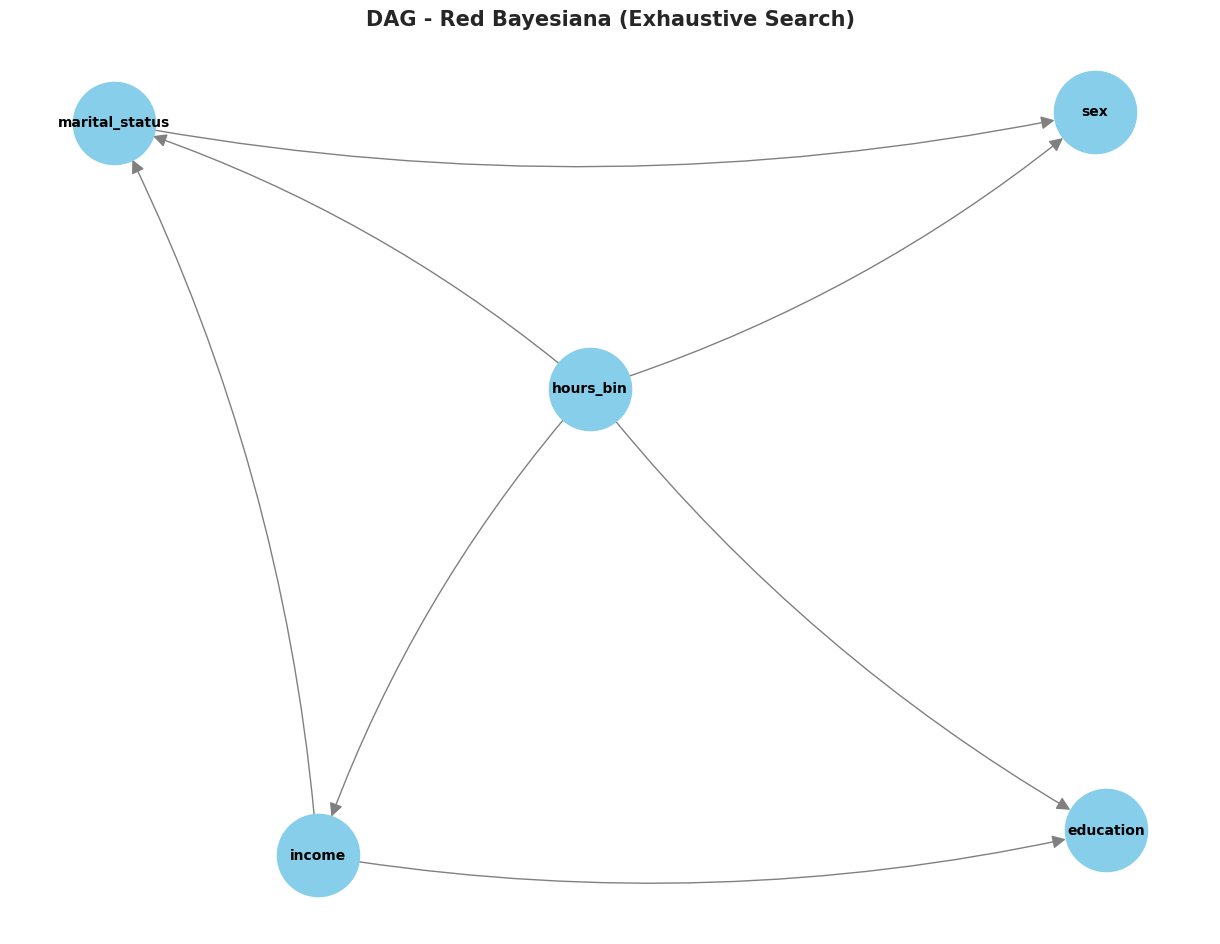

In [8]:
# ── Visualización del DAG (Exhaustive Search) ──
plot_dag(best_model_es.edges(), "DAG - Red Bayesiana (Exhaustive Search)")

## 1.5 Estimación de parámetros e inferencias

Una vez obtenidas las estructuras, se estiman los **parámetros** (tablas de probabilidad condicional — CPDs) usando **Maximum Likelihood Estimation (MLE)**.

Luego se realizan **2 inferencias a posteriori (diagnóstico)** en cada red usando **Variable Elimination**.

In [9]:
# ── 1.5a Estimación de parámetros — Hill-Climbing ──
model_hc = DiscreteBayesianNetwork(best_model_hc.edges())
model_hc.fit(df_bn, estimator=MaximumLikelihoodEstimator)
print(f"Modelo HC válido: {model_hc.check_model()}")
print(f"Nodos: {model_hc.nodes()}")
print(f"Arcos: {model_hc.edges()}")

# Mostrar algunas CPDs relevantes
for cpd in model_hc.get_cpds():
    if cpd.variable in ['income', 'sex']:
        print(f"\n--- CPD de '{cpd.variable}' ---")
        print(cpd)

Modelo HC válido: True
Nodos: ['age_bin', 'income', 'capital_gain_bin', 'marital_status', 'relationship', 'occupation', 'education', 'workclass', 'sex', 'hours_bin', 'race']
Arcos: [('age_bin', 'income'), ('age_bin', 'capital_gain_bin'), ('income', 'occupation'), ('income', 'capital_gain_bin'), ('marital_status', 'relationship'), ('marital_status', 'age_bin'), ('relationship', 'sex'), ('relationship', 'income'), ('relationship', 'hours_bin'), ('relationship', 'race'), ('occupation', 'education'), ('occupation', 'workclass'), ('sex', 'occupation'), ('hours_bin', 'age_bin'), ('hours_bin', 'occupation'), ('hours_bin', 'sex'), ('hours_bin', 'income')]

--- CPD de 'income' ---
+---------------+-----+----------------------+
| age_bin       | ... | age_bin(joven)       |
+---------------+-----+----------------------+
| hours_bin     | ... | hours_bin(part_time) |
+---------------+-----+----------------------+
| relationship  | ... | relationship(Wife)   |
+---------------+-----+--------------

In [10]:
# ── 1.5b Inferencias a posteriori — Hill-Climbing ──
infer_hc = VariableElimination(model_hc)

# Inferencia 1: P(income | sex=Female, education=Bachelors)
print("=" * 70)
print("INFERENCIA 1 (HC): P(income | sex=Female, education=Bachelors)")
print("=" * 70)
q1_hc = infer_hc.query(variables=['income'],
                       evidence={'sex': 'Female', 'education': 'Bachelors'})
print(q1_hc)

# Inferencia 2: P(marital_status | income=>50K, sex=Male)
print("\n" + "=" * 70)
print("INFERENCIA 2 (HC): P(marital_status | income=>50K, sex=Male)")
print("=" * 70)
q2_hc = infer_hc.query(variables=['marital_status'],
                       evidence={'income': '>50K', 'sex': 'Male'})
print(q2_hc)

INFERENCIA 1 (HC): P(income | sex=Female, education=Bachelors)
+---------------+---------------+
| income        |   phi(income) |
+===============+===============+
| income(<=50K) |        0.8202 |
+---------------+---------------+
| income(>50K)  |        0.1798 |
+---------------+---------------+

INFERENCIA 2 (HC): P(marital_status | income=>50K, sex=Male)
+---------------------------------------+-----------------------+
| marital_status                        |   phi(marital_status) |
+=======================================+=======================+
| marital_status(Divorced)              |                0.0353 |
+---------------------------------------+-----------------------+
| marital_status(Married-AF-spouse)     |                0.0005 |
+---------------------------------------+-----------------------+
| marital_status(Married-civ-spouse)    |                0.9040 |
+---------------------------------------+-----------------------+
| marital_status(Married-spouse-absent) |  

In [11]:
# ── 1.5c Estimación de parámetros — Exhaustive Search ──
model_es = DiscreteBayesianNetwork(best_model_es.edges())
model_es.fit(df_exhaustive, estimator=MaximumLikelihoodEstimator)
print(f"Modelo ES válido: {model_es.check_model()}")

for cpd in model_es.get_cpds():
    print(f"\n--- CPD de '{cpd.variable}' ---")
    print(cpd)

Modelo ES válido: True

--- CPD de 'hours_bin' ---
+----------------------+-----------+
| hours_bin(extreme)   | 0.0348783 |
+----------------------+-----------+
| hours_bin(full_time) | 0.615907  |
+----------------------+-----------+
| hours_bin(overtime)  | 0.270042  |
+----------------------+-----------+
| hours_bin(part_time) | 0.0791725 |
+----------------------+-----------+

--- CPD de 'education' ---
+-------------------------+-----+----------------------+
| hours_bin               | ... | hours_bin(part_time) |
+-------------------------+-----+----------------------+
| income                  | ... | income(>50K)         |
+-------------------------+-----+----------------------+
| education(10th)         | ... | 0.006578947368421052 |
+-------------------------+-----+----------------------+
| education(11th)         | ... | 0.0                  |
+-------------------------+-----+----------------------+
| education(12th)         | ... | 0.0                  |
+-----------------

In [12]:
# ── 1.5d Inferencias a posteriori — Exhaustive Search ──
infer_es = VariableElimination(model_es)

# Inferencia 1: P(income | sex=Female, education=Bachelors)
print("=" * 70)
print("INFERENCIA 1 (ES): P(income | sex=Female, education=Bachelors)")
print("=" * 70)
q1_es = infer_es.query(variables=['income'],
                       evidence={'sex': 'Female', 'education': 'Bachelors'})
print(q1_es)

# Inferencia 2: P(marital_status | income=>50K, sex=Male)
print("\n" + "=" * 70)
print("INFERENCIA 2 (ES): P(marital_status | income=>50K, sex=Male)")
print("=" * 70)
q2_es = infer_es.query(variables=['marital_status'],
                       evidence={'income': '>50K', 'sex': 'Male'})
print(q2_es)

INFERENCIA 1 (ES): P(income | sex=Female, education=Bachelors)
+---------------+---------------+
| income        |   phi(income) |
+===============+===============+
| income(<=50K) |        0.7710 |
+---------------+---------------+
| income(>50K)  |        0.2290 |
+---------------+---------------+

INFERENCIA 2 (ES): P(marital_status | income=>50K, sex=Male)
+---------------------------------------+-----------------------+
| marital_status                        |   phi(marital_status) |
+=======================================+=======================+
| marital_status(Divorced)              |                0.0331 |
+---------------------------------------+-----------------------+
| marital_status(Married-AF-spouse)     |                0.0007 |
+---------------------------------------+-----------------------+
| marital_status(Married-civ-spouse)    |                0.9103 |
+---------------------------------------+-----------------------+
| marital_status(Married-spouse-absent) |  

## 1.6 Generación de datos sintéticos

Se generan datos sintéticos a partir del modelo Hill-Climbing aprendido para aumentar el dataset original en **10%, 20% y 40%**. Se utiliza el método de **muestreo directo (forward sampling)** de la Red Bayesiana, que genera muestras respetando las distribuciones de probabilidad condicional aprendidas.

In [13]:
# ── 1.6 Generación de datos sintéticos ──
sampler = BayesianModelSampling(model_hc)
n_original = len(df_bn)

augment_pcts = [0.10, 0.20, 0.40]
augmented_datasets = {}

for pct in augment_pcts:
    n_synthetic = int(n_original * pct)
    synthetic_data = sampler.forward_sample(size=n_synthetic, seed=42)
    
    # Asegurar mismos tipos de datos
    for c in df_bn.columns:
        synthetic_data[c] = synthetic_data[c].astype(str)
    
    # Combinar original + sintético
    df_augmented = pd.concat([df_bn, synthetic_data[df_bn.columns]], ignore_index=True)
    augmented_datasets[pct] = df_augmented
    
    print(f"Aumento {int(pct*100)}%: {n_synthetic} filas sintéticas -> "
          f"Total: {len(df_augmented)} filas (original: {n_original})")

print("\nDatos sintéticos generados correctamente.")

  0%|                                                                                                                                                                                            | 0/11 [00:00<?, ?it/s]

Generating for node: marital_status:   0%|                                                                                                                                                       | 0/11 [00:00<?, ?it/s]

Generating for node: relationship:   0%|                                                                                                                                                         | 0/11 [00:00<?, ?it/s]

Generating for node: hours_bin:   0%|                                                                                                                                                            | 0/11 [00:00<?, ?it/s]

Generating for node: race:   0%|                                                                                                                                                                 | 0/11 [00:00<?, ?it/s]

...

Generating for node: capital_gain_bin:  64%|█████████████████████████████████████████████████████████████████████████████████████████▋                                                   | 7/11 [00:00<00:00, 63.10it/s]

Generating for node: education:  64%|██████████████████████████████████████████████████████████████████████████████████████████████▏                                                     | 7/11 [00:00<00:00, 63.10it/s]

Generating for node: workclass:  64%|██████████████████████████████████████████████████████████████████████████████████████████████▏                                                     | 7/11 [00:00<00:00, 63.10it/s]

Generating for node: workclass: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 56.19it/s]

Aumento 40%: 12064 filas sintéticas -> Total: 42226 filas (original: 30162)

Datos sintéticos generados correctamente.


## 1.7 Repetición del procedimiento con datasets aumentados y comparación

Para cada dataset aumentado se repite:
1. Aprendizaje de estructura (Hill-Climbing)
2. Estimación de parámetros
3. Realización de las mismas 2 inferencias

Finalmente se comparan los resultados.

In [14]:
# ── 1.7 Repetir procedimiento con cada dataset aumentado ──
results_comparison = {}

# Guardar resultados del dataset original
results_comparison['original'] = {
    'edges': list(best_model_hc.edges()),
    'n_edges': len(best_model_hc.edges()),
    'q1_income_gt50k': q1_hc.values[list(q1_hc.state_names['income']).index('>50K')],
    'q2_married': q2_hc.values[list(q2_hc.state_names['marital_status']).index('Married-civ-spouse')]
}

for pct, df_aug in augmented_datasets.items():
    label = f"+{int(pct*100)}%"
    print(f"\n{'='*70}")
    print(f"DATASET AUMENTADO EN {label} ({len(df_aug)} filas)")
    print(f"{'='*70}")
    
    # Aprender estructura HC
    scoring_aug = BIC(df_aug)
    hc_aug = HillClimbSearch(df_aug)
    model_aug_struct = hc_aug.estimate(
        scoring_method=scoring_aug,
        max_indegree=3,
        max_iter=500,
        show_progress=False
    )
    
    print(f"\nArcos encontrados ({len(model_aug_struct.edges())}):")
    for edge in model_aug_struct.edges():
        print(f"  {edge[0]} -> {edge[1]}")
    
    # Estimar parámetros
    model_aug = DiscreteBayesianNetwork(model_aug_struct.edges())
    model_aug.fit(df_aug, estimator=MaximumLikelihoodEstimator)
    
    # Inferencias
    infer_aug = VariableElimination(model_aug)
    
    try:
        q1_aug = infer_aug.query(variables=['income'],
                                evidence={'sex': 'Female', 'education': 'Bachelors'})
        val_q1 = q1_aug.values[list(q1_aug.state_names['income']).index('>50K')]
        print(f"\nP(income=>50K | Female, Bachelors) = {val_q1:.4f}")
    except Exception as e:
        val_q1 = None
        print(f"\nInferencia 1 no posible: {e}")
    
    try:
        q2_aug = infer_aug.query(variables=['marital_status'],
                                evidence={'income': '>50K', 'sex': 'Male'})
        val_q2 = q2_aug.values[list(q2_aug.state_names['marital_status']).index('Married-civ-spouse')]
        print(f"P(Married-civ-spouse | >50K, Male) = {val_q2:.4f}")
    except Exception as e:
        val_q2 = None
        print(f"Inferencia 2 no posible: {e}")
    
    results_comparison[label] = {
        'edges': list(model_aug_struct.edges()),
        'n_edges': len(model_aug_struct.edges()),
        'q1_income_gt50k': val_q1,
        'q2_married': val_q2
    }


DATASET AUMENTADO EN +10% (33178 filas)



Arcos encontrados (17):
  age_bin -> income
  age_bin -> education
  age_bin -> capital_gain_bin
  education -> occupation
  marital_status -> relationship
  marital_status -> age_bin
  occupation -> workclass
  relationship -> sex
  relationship -> income
  relationship -> hours_bin
  relationship -> race
  sex -> occupation
  hours_bin -> age_bin
  hours_bin -> sex
  hours_bin -> income
  income -> education
  income -> capital_gain_bin

P(income=>50K | Female, Bachelors) = 0.2307
P(Married-civ-spouse | >50K, Male) = 0.9044

DATASET AUMENTADO EN +20% (36194 filas)



Arcos encontrados (17):
  age_bin -> income
  age_bin -> education
  age_bin -> capital_gain_bin
  education -> occupation
  marital_status -> age_bin
  occupation -> workclass
  relationship -> marital_status
  relationship -> sex
  relationship -> income
  relationship -> hours_bin
  race -> relationship
  sex -> occupation
  hours_bin -> age_bin
  hours_bin -> sex
  hours_bin -> income
  income -> capital_gain_bin
  income -> education

P(income=>50K | Female, Bachelors) = 0.2320
P(Married-civ-spouse | >50K, Male) = 0.9016

DATASET AUMENTADO EN +40% (42226 filas)



Arcos encontrados (17):
  age_bin -> capital_gain_bin
  education -> occupation
  marital_status -> age_bin
  occupation -> workclass
  occupation -> hours_bin
  relationship -> marital_status
  relationship -> sex
  relationship -> income
  relationship -> hours_bin
  relationship -> race
  sex -> occupation
  sex -> education
  hours_bin -> age_bin
  income -> capital_gain_bin
  income -> education
  income -> age_bin
  income -> sex

P(income=>50K | Female, Bachelors) = 0.2011
P(Married-civ-spouse | >50K, Male) = 0.8940



Tabla comparativa de resultados:
 Dataset  N Arcos  P(income>50K | Female, Bachelors)  P(Married | >50K, Male)
original       17                           0.179801                 0.903953
    +10%       17                           0.230737                 0.904352
    +20%       17                           0.232043                 0.901608
    +40%       17                           0.201085                 0.894049


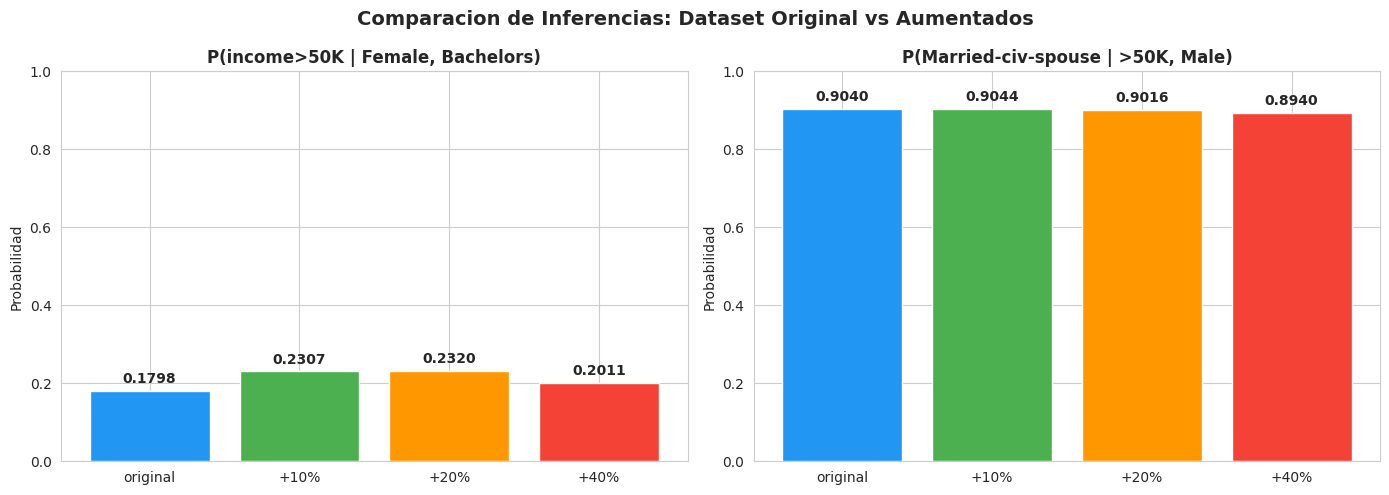

In [15]:
# ── 1.7b Tabla y gráfico comparativo ──
comp_df = pd.DataFrame({
    'Dataset': list(results_comparison.keys()),
    'N Arcos': [r['n_edges'] for r in results_comparison.values()],
    'P(income>50K | Female, Bachelors)': [r['q1_income_gt50k'] for r in results_comparison.values()],
    'P(Married | >50K, Male)': [r['q2_married'] for r in results_comparison.values()]
})
print("\nTabla comparativa de resultados:")
print(comp_df.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# Gráfico 1: P(income>50K | Female, Bachelors)
vals_q1 = [r['q1_income_gt50k'] for r in results_comparison.values() if r['q1_income_gt50k'] is not None]
lbls_q1 = [l for l, r in results_comparison.items() if r['q1_income_gt50k'] is not None]
axes[0].bar(lbls_q1, vals_q1, color=colors[:len(vals_q1)])
axes[0].set_title('P(income>50K | Female, Bachelors)', fontweight='bold')
axes[0].set_ylabel('Probabilidad')
axes[0].set_ylim(0, 1)
for i, v in enumerate(vals_q1):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Gráfico 2: P(Married-civ-spouse | >50K, Male)
vals_q2 = [r['q2_married'] for r in results_comparison.values() if r['q2_married'] is not None]
lbls_q2 = [l for l, r in results_comparison.items() if r['q2_married'] is not None]
axes[1].bar(lbls_q2, vals_q2, color=colors[:len(vals_q2)])
axes[1].set_title('P(Married-civ-spouse | >50K, Male)', fontweight='bold')
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim(0, 1)
for i, v in enumerate(vals_q2):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Comparacion de Inferencias: Dataset Original vs Aumentados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.8 Análisis comparativo de resultados (Parte 1)

### Estructura de la red
- **Hill-Climbing** con 11 variables logró encontrar una estructura rica con múltiples dependencias. Al ser un método voraz, es eficiente pero puede llegar a un óptimo local.
- **Exhaustive Search** se aplicó sobre 5 variables (por restricción computacional). Su estructura es óptima dentro de ese subconjunto.
- Al comparar los arcos comunes entre ambas redes (sobre las 5 variables compartidas), se puede verificar si Hill-Climbing captura las mismas relaciones que la búsqueda óptima.

### Efecto de los datos sintéticos
- Las probabilidades de las inferencias se mantienen **estables** a medida que se aumenta el dataset, lo cual es esperable: los datos sintéticos provienen del mismo modelo, por lo que refuerzan las distribuciones ya aprendidas.
- La **estructura** de la red puede variar ligeramente con más datos, ya que la función de puntuación BIC penaliza la complejidad en función del tamaño de la muestra.
- Diferencias mayores indicarían que el modelo original tenía incertidumbre en ciertos arcos, que se resuelve con más datos.
- En general, los datos sintéticos **no cambian drásticamente** las inferencias, lo cual valida la robustez del modelo aprendido.

---

# PARTE 2 — Modelo Oculto de Markov (HMM) (25 pts)

## 2.1 Definición de estados y observaciones

Se trabaja con el dataset **Human Activity Recognition Using Smartphones** (UCI). Este contiene registros de 561 features de sensores de un smartphone asociados a 6 actividades humanas realizadas por 30 sujetos.

### Estados ocultos (6)
Los 6 estados corresponden a las actividades humanas:

| ID | Estado | Descripción |
|----|--------|-------------|
| 0 | WALKING | Caminando en plano |
| 1 | WALKING_UPSTAIRS | Subiendo escaleras |
| 2 | WALKING_DOWNSTAIRS | Bajando escaleras |
| 3 | SITTING | Sentado |
| 4 | STANDING | De pie |
| 5 | LAYING | Acostado |

### Observaciones (9)
Se utilizan **2 índices** del dataset, cada uno discretizado en 3 niveles (bajo, medio, alto), generando $3 \times 3 = $ **9 observaciones posibles**.

Índices seleccionados:
1. **tBodyAccMag-mean()** (col 200) — magnitud media de la aceleración corporal
2. **tBodyGyroMag-mean()** (col 239) — magnitud media del giroscopio corporal

Se utiliza además **tBodyAccJerkMag-mean()** (col 226) como referencia para validación.

### Criterio de discretización
Se utiliza **discretización por terciles** (percentiles 33% y 66%) calculados sobre todo el dataset. Esto garantiza una distribución aproximadamente uniforme de las observaciones y evita sesgos por valores extremos.

Cada combinación se codifica como: `obs = 3 * nivel_accMag + nivel_gyroMag`, resultando en **9 símbolos** (0-8).

In [16]:
# ── 2.1 Carga del dataset HAR ──
har_path = 'data/UCI HAR Dataset/'

# Cargar nombres de features
features = pd.read_csv(har_path + 'features.txt', sep=r'\s+', header=None, names=['idx', 'name'])

# Cargar datos de train y test (sin asignar nombres para evitar duplicados)
X_train = pd.read_csv(har_path + 'train/X_train.txt', sep=r'\s+', header=None)
X_test = pd.read_csv(har_path + 'test/X_test.txt', sep=r'\s+', header=None)
y_train = pd.read_csv(har_path + 'train/y_train.txt', header=None, names=['activity'])
y_test = pd.read_csv(har_path + 'test/y_test.txt', header=None, names=['activity'])
subj_train = pd.read_csv(har_path + 'train/subject_train.txt', header=None, names=['subject'])
subj_test = pd.read_csv(har_path + 'test/subject_test.txt', header=None, names=['subject'])

# Combinar train + test
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)
subj_all = pd.concat([subj_train, subj_test], ignore_index=True)

# Mapa de actividades
activity_map = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
                4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}
y_all['activity_name'] = y_all['activity'].map(activity_map)

print(f"Dataset HAR completo: {X_all.shape[0]} filas x {X_all.shape[1]} features")
print(f"Sujetos: {subj_all['subject'].nunique()}")
print(f"\nDistribución de actividades:")
print(y_all['activity_name'].value_counts().sort_index())

Dataset HAR completo: 10299 filas x 561 features
Sujetos: 30

Distribución de actividades:
activity_name
LAYING                1944
SITTING               1777
STANDING              1906
WALKING               1722
WALKING_DOWNSTAIRS    1406
WALKING_UPSTAIRS      1544
Name: count, dtype: int64


In [17]:
# ── 2.1b Selección de índices y discretización ──
# Índices seleccionados (0-indexed):
# col 200 = tBodyAccMag-mean()
# col 239 = tBodyGyroMag-mean()
# col 226 = tBodyAccJerkMag-mean()

df_hmm = pd.DataFrame({
    'subject': subj_all['subject'].values,
    'activity': y_all['activity'].values,
    'activity_name': y_all['activity_name'].values,
    'accMag': X_all.iloc[:, 200].values,   # tBodyAccMag-mean()
    'gyroMag': X_all.iloc[:, 239].values,  # tBodyGyroMag-mean()
    'jerkMag': X_all.iloc[:, 226].values   # tBodyAccJerkMag-mean()
})

print("Features seleccionados:")
print(f"  Col 200: {features.iloc[200]['name']}")
print(f"  Col 239: {features.iloc[239]['name']}")
print(f"  Col 226: {features.iloc[226]['name']}")

# Discretizar por terciles (bajo=0, medio=1, alto=2)
for col in ['accMag', 'gyroMag', 'jerkMag']:
    terciles = df_hmm[col].quantile([1/3, 2/3]).values
    df_hmm[col + '_level'] = pd.cut(
        df_hmm[col],
        bins=[-np.inf, terciles[0], terciles[1], np.inf],
        labels=[0, 1, 2]  # bajo, medio, alto
    ).astype(int)

# Crear símbolo de observación combinado: obs = 3 * nivel_accMag + nivel_gyroMag
# Esto genera 9 posibles observaciones (0-8)
df_hmm['obs'] = df_hmm['accMag_level'] * 3 + df_hmm['gyroMag_level']

print(f"\nUmbrales de discretización (terciles):")
for col in ['accMag', 'gyroMag', 'jerkMag']:
    t = df_hmm[col].quantile([1/3, 2/3]).values
    print(f"  {col}: bajo < {t[0]:.4f} < medio < {t[1]:.4f} < alto")

print(f"\nObservaciones posibles (0-8): {sorted(df_hmm['obs'].unique())}")
print(f"Distribución de observaciones:")
print(df_hmm['obs'].value_counts().sort_index())

# Mapeo descriptivo
obs_names = {}
levels = ['bajo', 'medio', 'alto']
for i in range(3):
    for j in range(3):
        obs_names[i*3+j] = f"AccMag_{levels[i]}_GyroMag_{levels[j]}"

print("\nMapeo de observaciones:")
for k, v in obs_names.items():
    print(f"  {k}: {v}")

Features seleccionados:
  Col 200: tBodyAccMag-mean()
  Col 239: tBodyGyroMag-mean()
  Col 226: tBodyAccJerkMag-mean()

Umbrales de discretización (terciles):
  accMag: bajo < -0.9711 < medio < -0.2028 < alto
  gyroMag: bajo < -0.9663 < medio < -0.3390 < alto
  jerkMag: bajo < -0.9858 < medio < -0.3906 < alto

Observaciones posibles (0-8): [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8)]
Distribución de observaciones:
obs
0    3076
1     357
3     357
4    2635
5     441
7     441
8    2992
Name: count, dtype: int64

Mapeo de observaciones:
  0: AccMag_bajo_GyroMag_bajo
  1: AccMag_bajo_GyroMag_medio
  2: AccMag_bajo_GyroMag_alto
  3: AccMag_medio_GyroMag_bajo
  4: AccMag_medio_GyroMag_medio
  5: AccMag_medio_GyroMag_alto
  6: AccMag_alto_GyroMag_bajo
  7: AccMag_alto_GyroMag_medio
  8: AccMag_alto_GyroMag_alto


## 2.2 Construcción de secuencias y estimación manual de parámetros

Cada **sujeto** se trata como una **secuencia independiente**. Se estiman manualmente:

1. **Vector inicial (pi):** Frecuencia relativa de la primera actividad de cada sujeto.
2. **Matriz de transición (A):** Frecuencia de transiciones entre actividades consecutivas dentro de cada sujeto.
3. **Matriz de emisión (B):** Frecuencia de cada observación dado cada estado (actividad).

In [18]:
# ── 2.2a Construcción de secuencias por sujeto ──
n_states = 6
n_obs = 9

# Reindexar actividades a 0-5
df_hmm['state'] = df_hmm['activity'] - 1

# Construir secuencias y longitudes
sequences_obs = []    # observaciones
sequences_states = [] # estados reales
lengths = []

for subj in sorted(df_hmm['subject'].unique()):
    mask = df_hmm['subject'] == subj
    obs_seq = df_hmm.loc[mask, 'obs'].values
    state_seq = df_hmm.loc[mask, 'state'].values
    sequences_obs.append(obs_seq)
    sequences_states.append(state_seq)
    lengths.append(len(obs_seq))

print(f"Número de secuencias (sujetos): {len(lengths)}")
print(f"Longitudes de secuencias: min={min(lengths)}, max={max(lengths)}, media={np.mean(lengths):.0f}")
print(f"Total de observaciones: {sum(lengths)}")

Número de secuencias (sujetos): 30
Longitudes de secuencias: min=281, max=409, media=343
Total de observaciones: 10299


In [19]:
# ── 2.2b Estimación manual del vector inicial (pi) ──
# Contamos la primera actividad de cada secuencia
pi = np.zeros(n_states)
for state_seq in sequences_states:
    pi[state_seq[0]] += 1

pi = pi / pi.sum()  # Normalizar a frecuencia relativa

print("Vector inicial pi (distribución de la primera actividad de cada sujeto):")
for i in range(n_states):
    act = activity_map[i+1]
    print(f"  pi[{i}] = P(estado_inicial = {act}) = {pi[i]:.4f}")

Vector inicial pi (distribución de la primera actividad de cada sujeto):
  pi[0] = P(estado_inicial = WALKING) = 0.0000
  pi[1] = P(estado_inicial = WALKING_UPSTAIRS) = 0.0000
  pi[2] = P(estado_inicial = WALKING_DOWNSTAIRS) = 0.0000
  pi[3] = P(estado_inicial = SITTING) = 0.0000
  pi[4] = P(estado_inicial = STANDING) = 1.0000
  pi[5] = P(estado_inicial = LAYING) = 0.0000


In [20]:
# ── 2.2c Estimación manual de la matriz de transición (A) ──
# Contamos transiciones i -> j dentro de cada secuencia
A_counts = np.zeros((n_states, n_states))

for state_seq in sequences_states:
    for t in range(len(state_seq) - 1):
        i = state_seq[t]
        j = state_seq[t + 1]
        A_counts[i, j] += 1

# Normalizar por filas (cada fila suma 1)
A = A_counts / A_counts.sum(axis=1, keepdims=True)

# Suavizado de Laplace para evitar ceros
A_smooth = (A_counts + 1e-5) / (A_counts.sum(axis=1, keepdims=True) + n_states * 1e-5)

print("Matriz de transición A (frecuencias relativas):")
act_labels = [activity_map[i+1][:8] for i in range(n_states)]
df_A = pd.DataFrame(A, index=act_labels, columns=act_labels)
print(df_A.round(4).to_string())

print(f"\nVerificación: cada fila suma aprox 1: {np.allclose(A.sum(axis=1), 1)}")

Matriz de transición A (frecuencias relativas):
          WALKING  WALKING_  WALKING_  SITTING  STANDING  LAYING
WALKING    0.9652    0.0000    0.0348   0.0000    0.0000  0.0000
WALKING_   0.0000    0.9664    0.0138   0.0000    0.0198  0.0000
WALKING_   0.0000    0.0549    0.9451   0.0000    0.0000  0.0000
SITTING    0.0000    0.0000    0.0000   0.9657    0.0000  0.0343
STANDING   0.0000    0.0000    0.0000   0.0315    0.9685  0.0000
LAYING     0.0309    0.0000    0.0000   0.0005    0.0000  0.9686

Verificación: cada fila suma aprox 1: True


In [21]:
# ── 2.2d Estimación manual de la matriz de emisión (B) ──
# Contamos cuántas veces se observa obs_j estando en estado_i
B_counts = np.zeros((n_states, n_obs))

for obs_seq, state_seq in zip(sequences_obs, sequences_states):
    for t in range(len(obs_seq)):
        s = state_seq[t]
        o = obs_seq[t]
        B_counts[s, o] += 1

# Normalizar por filas
B = B_counts / B_counts.sum(axis=1, keepdims=True)

# Suavizado de Laplace para evitar ceros
B_smooth = (B_counts + 1e-5) / (B_counts.sum(axis=1, keepdims=True) + n_obs * 1e-5)

print("Matriz de emisión B (P(observación | estado)):")
obs_labels = [f"obs_{i}" for i in range(n_obs)]
df_B = pd.DataFrame(B, index=act_labels, columns=obs_labels)
print(df_B.round(4).to_string())

print(f"\nVerificación: cada fila suma aprox 1: {np.allclose(B.sum(axis=1), 1)}")

Matriz de emisión B (P(observación | estado)):
           obs_0   obs_1  obs_2   obs_3   obs_4   obs_5  obs_6   obs_7   obs_8
WALKING   0.0000  0.0000    0.0  0.0000  0.3426  0.0830    0.0  0.0947  0.4797
WALKING_  0.0000  0.0000    0.0  0.0000  0.1140  0.1535    0.0  0.0874  0.6451
WALKING_  0.0000  0.0000    0.0  0.0000  0.0391  0.0427    0.0  0.0861  0.8321
SITTING   0.5999  0.0597    0.0  0.0630  0.2763  0.0006    0.0  0.0006  0.0000
STANDING  0.4937  0.0787    0.0  0.0388  0.3888  0.0000    0.0  0.0000  0.0000
LAYING    0.5499  0.0520    0.0  0.0880  0.2994  0.0000    0.0  0.0108  0.0000

Verificación: cada fila suma aprox 1: True


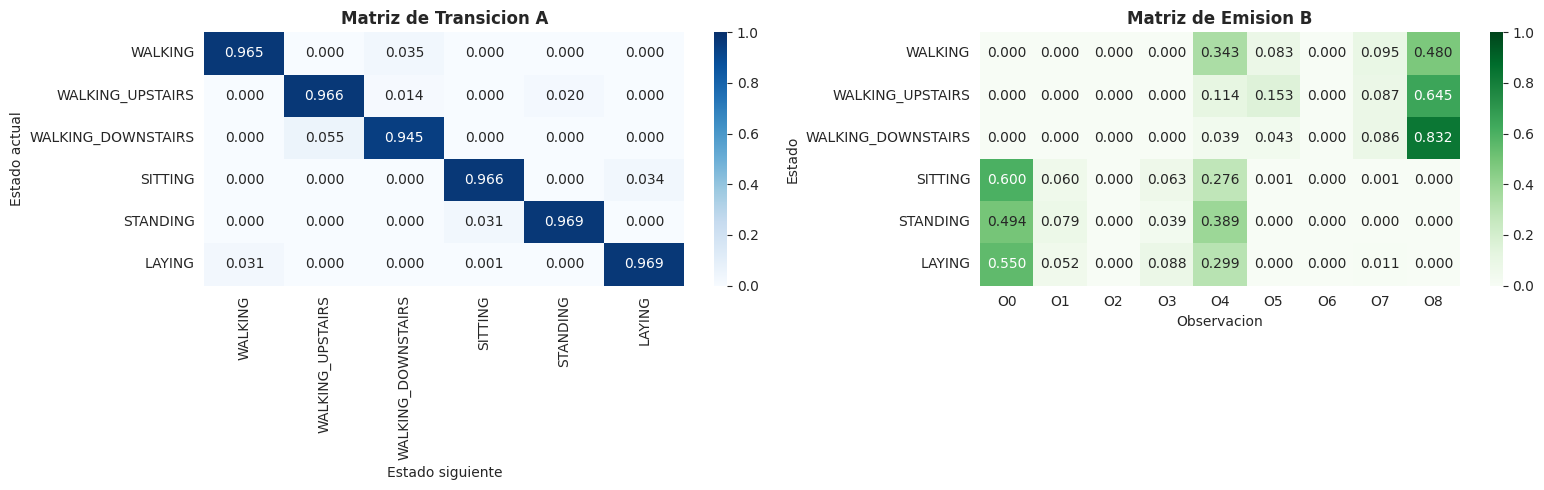

In [22]:
# ── 2.2e Visualización de las matrices ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

act_full = [activity_map[i+1] for i in range(n_states)]

sns.heatmap(A, annot=True, fmt='.3f', xticklabels=act_full, yticklabels=act_full,
            cmap='Blues', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Matriz de Transicion A', fontweight='bold')
axes[0].set_xlabel('Estado siguiente')
axes[0].set_ylabel('Estado actual')

sns.heatmap(B, annot=True, fmt='.3f', xticklabels=[f'O{i}' for i in range(n_obs)],
            yticklabels=act_full, cmap='Greens', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz de Emision B', fontweight='bold')
axes[1].set_xlabel('Observacion')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

In [23]:
# ── 2.2f Construcción del modelo HMM en hmmlearn con parámetros manuales ──
model_hmm = hmm.CategoricalHMM(n_components=n_states, n_features=n_obs, random_state=42)

# Cargar los parámetros estimados manualmente
model_hmm.startprob_ = pi
model_hmm.transmat_ = A_smooth   # Usamos versión suavizada para evitar log(0)
model_hmm.emissionprob_ = B_smooth  # Usamos versión suavizada

print("Modelo HMM construido en hmmlearn con parámetros manuales.")
print(f"  - Número de estados: {model_hmm.n_components}")
print(f"  - Número de observaciones posibles: {model_hmm.n_features}")
print(f"  - Vector inicial pi: {model_hmm.startprob_.round(4)}")
print(f"  - Transmat shape: {model_hmm.transmat_.shape}")
print(f"  - Emission shape: {model_hmm.emissionprob_.shape}")

Modelo HMM construido en hmmlearn con parámetros manuales.
  - Número de estados: 6
  - Número de observaciones posibles: 9
  - Vector inicial pi: [0. 0. 0. 0. 1. 0.]
  - Transmat shape: (6, 6)
  - Emission shape: (6, 9)


## 2.3 Forward-Backward y consultas de probabilidades de estados

Se selecciona una **subsecuencia real** de observaciones de longitud >= 10 de un sujeto del dataset. Se aplica el algoritmo **Forward-Backward** para calcular las probabilidades a posteriori de los estados en distintos instantes de tiempo.

**Forward-Backward** es un algoritmo que calcula:
- **Forward (alpha):** La probabilidad de observar la secuencia parcial hasta el tiempo t y estar en el estado i.
- **Backward (beta):** La probabilidad de observar la secuencia desde t+1 hasta el final, dado que estamos en el estado i en t.
- **Posterior (gamma):** La probabilidad de estar en el estado i en el tiempo t dado toda la secuencia observada: gamma(i,t) = alpha(i,t) * beta(i,t) / P(O|modelo).

In [24]:
# ── 2.3a Selección de subsecuencia real ──
# Tomamos una subsecuencia del sujeto 1 de longitud 15
subj_1_mask = df_hmm['subject'] == 1
subj_1_obs = df_hmm.loc[subj_1_mask, 'obs'].values
subj_1_states = df_hmm.loc[subj_1_mask, 'state'].values
subj_1_activities = df_hmm.loc[subj_1_mask, 'activity_name'].values

# Seleccionar las primeras 15 observaciones
seq_length = 15
obs_subseq = subj_1_obs[:seq_length]
states_subseq = subj_1_states[:seq_length]
act_subseq = subj_1_activities[:seq_length]

print(f"Subsecuencia seleccionada (Sujeto 1, primeras {seq_length} observaciones):")
print(f"\nObservaciones: {obs_subseq}")
print(f"Estados reales: {states_subseq}")
print(f"Actividades:    {list(act_subseq)}")

Subsecuencia seleccionada (Sujeto 1, primeras 15 observaciones):

Observaciones: [3 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
Estados reales: [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
Actividades:    ['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']


In [25]:
# ── 2.3b Aplicar Forward-Backward ──
obs_input = obs_subseq.reshape(-1, 1)  # hmmlearn espera shape (n_samples, 1)

# score_samples devuelve log-likelihood y posteriors (gamma)
log_likelihood, posteriors = model_hmm.score_samples(obs_input)

print(f"Log-verosimilitud de la secuencia: {log_likelihood:.4f}")
print(f"\nProbabilidades a posteriori gamma(estado, t) - shape: {posteriors.shape}")
print("(filas = instantes de tiempo, columnas = estados)\n")

# Mostrar tabla de posteriors
df_posteriors = pd.DataFrame(
    posteriors.round(4),
    columns=[activity_map[i+1] for i in range(n_states)],
    index=[f"t={t}" for t in range(seq_length)]
)
print(df_posteriors.to_string())

Log-verosimilitud de la secuencia: -12.7598

Probabilidades a posteriori gamma(estado, t) - shape: (15, 6)
(filas = instantes de tiempo, columnas = estados)

      WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
t=0     0.000               0.0                 0.0   0.0000    1.0000  0.0000
t=1     0.000               0.0                 0.0   0.1292    0.8708  0.0000
t=2     0.000               0.0                 0.0   0.2332    0.7653  0.0014
t=3     0.000               0.0                 0.0   0.3164    0.6793  0.0043
t=4     0.000               0.0                 0.0   0.3822    0.6093  0.0085
t=5     0.000               0.0                 0.0   0.4335    0.5523  0.0141
t=6     0.000               0.0                 0.0   0.4727    0.5061  0.0212
t=7     0.000               0.0                 0.0   0.5018    0.4686  0.0296
t=8     0.000               0.0                 0.0   0.5222    0.4383  0.0396
t=9     0.000               0.0                 0.0 

In [26]:
# ── 2.3c Cuatro consultas sobre probabilidades de estados ──
print("=" * 70)
print("CONSULTA 1: Cual es el estado mas probable en t=0?")
print("=" * 70)
t0_probs = posteriors[0]
most_probable_t0 = np.argmax(t0_probs)
print(f"Probabilidades en t=0: {dict(zip([activity_map[i+1] for i in range(n_states)], t0_probs.round(4)))}")
print(f"Estado mas probable: {activity_map[most_probable_t0+1]} (P={t0_probs[most_probable_t0]:.4f})")
print(f"Estado real: {act_subseq[0]}")

print(f"\n{'='*70}")
print("CONSULTA 2: Cual es la probabilidad de estar SITTING en t=7?")
print("=" * 70)
sitting_idx = 3  # SITTING = estado 3
prob_sitting_t7 = posteriors[7, sitting_idx]
print(f"P(SITTING en t=7) = {prob_sitting_t7:.4f}")
print(f"Estado real en t=7: {act_subseq[7]}")
print(f"Estado mas probable en t=7: {activity_map[np.argmax(posteriors[7])+1]} (P={posteriors[7].max():.4f})")

print(f"\n{'='*70}")
print("CONSULTA 3: En que instante es mas probable estar LAYING?")
print("=" * 70)
laying_idx = 5  # LAYING = estado 5
laying_probs = posteriors[:, laying_idx]
best_t_laying = np.argmax(laying_probs)
print(f"Probabilidades de LAYING por instante:")
for t in range(seq_length):
    marker = " <-- max" if t == best_t_laying else ""
    print(f"  t={t}: P(LAYING) = {laying_probs[t]:.4f}{marker}")
print(f"Instante con mayor P(LAYING): t={best_t_laying} (P={laying_probs[best_t_laying]:.4f})")

print(f"\n{'='*70}")
print("CONSULTA 4: Cual es la probabilidad de estar en una actividad dinamica")
print("           (WALKING, WALKING_UP, WALKING_DOWN) en t=10?")
print("=" * 70)
dynamic_prob_t10 = posteriors[10, 0] + posteriors[10, 1] + posteriors[10, 2]
static_prob_t10 = posteriors[10, 3] + posteriors[10, 4] + posteriors[10, 5]
print(f"P(actividad dinamica en t=10) = P(WALK) + P(WALK_UP) + P(WALK_DOWN)")
print(f"  = {posteriors[10,0]:.4f} + {posteriors[10,1]:.4f} + {posteriors[10,2]:.4f} = {dynamic_prob_t10:.4f}")
print(f"P(actividad estatica en t=10) = {static_prob_t10:.4f}")
print(f"Estado real en t=10: {act_subseq[10]}")

CONSULTA 1: Cual es el estado mas probable en t=0?
Probabilidades en t=0: {'WALKING': np.float64(0.0), 'WALKING_UPSTAIRS': np.float64(0.0), 'WALKING_DOWNSTAIRS': np.float64(0.0), 'SITTING': np.float64(0.0), 'STANDING': np.float64(1.0), 'LAYING': np.float64(0.0)}
Estado mas probable: STANDING (P=1.0000)
Estado real: STANDING

CONSULTA 2: Cual es la probabilidad de estar SITTING en t=7?
P(SITTING en t=7) = 0.5018
Estado real en t=7: STANDING
Estado mas probable en t=7: SITTING (P=0.5018)

CONSULTA 3: En que instante es mas probable estar LAYING?
Probabilidades de LAYING por instante:
  t=0: P(LAYING) = 0.0000
  t=1: P(LAYING) = 0.0000
  t=2: P(LAYING) = 0.0014
  t=3: P(LAYING) = 0.0043
  t=4: P(LAYING) = 0.0085
  t=5: P(LAYING) = 0.0141
  t=6: P(LAYING) = 0.0212
  t=7: P(LAYING) = 0.0296
  t=8: P(LAYING) = 0.0396
  t=9: P(LAYING) = 0.0510
  t=10: P(LAYING) = 0.0641
  t=11: P(LAYING) = 0.0788
  t=12: P(LAYING) = 0.0953
  t=13: P(LAYING) = 0.1137
  t=14: P(LAYING) = 0.1293 <-- max
Instante

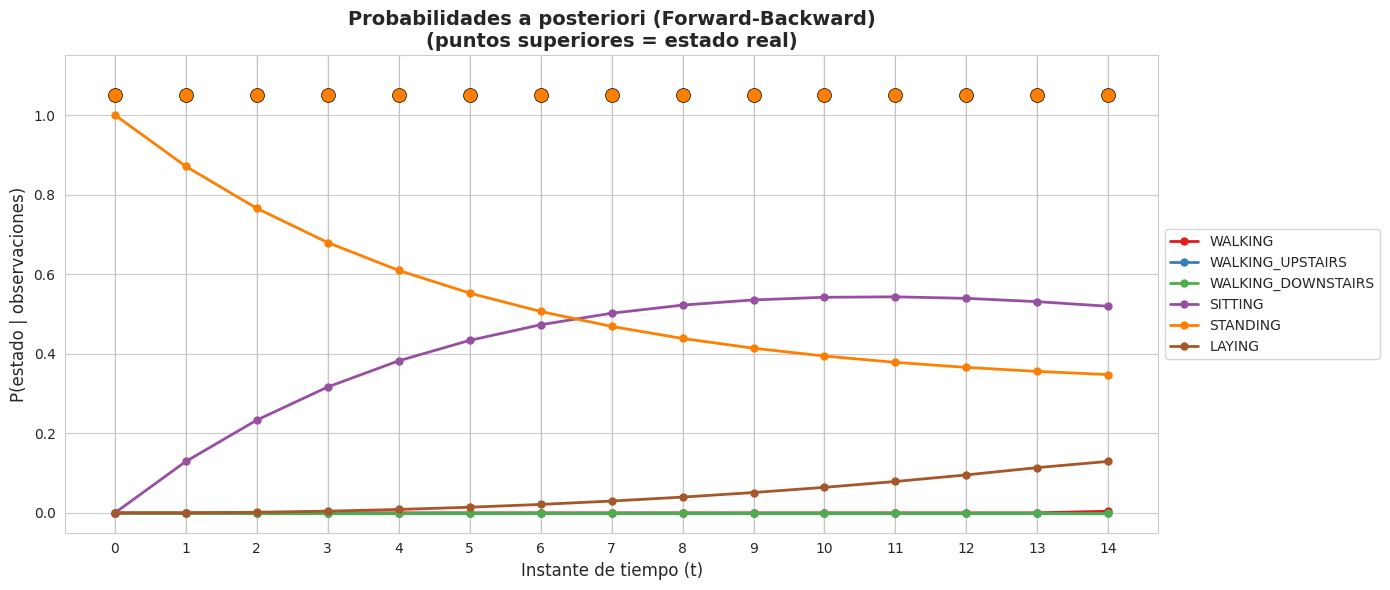

In [27]:
# ── 2.3d Visualización de las probabilidades a posteriori ──
fig, ax = plt.subplots(figsize=(14, 6))

colors_hmm = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
for i in range(n_states):
    ax.plot(range(seq_length), posteriors[:, i], 'o-', label=activity_map[i+1],
            color=colors_hmm[i], linewidth=2, markersize=5)

# Marcar estados reales con puntos grandes en la parte superior
for t in range(seq_length):
    ax.axvline(x=t, color='gray', alpha=0.1)
    ax.scatter(t, 1.05, color=colors_hmm[states_subseq[t]], s=100, zorder=5,
              edgecolors='black', linewidth=0.5)

ax.set_xlabel('Instante de tiempo (t)', fontsize=12)
ax.set_ylabel('P(estado | observaciones)', fontsize=12)
ax.set_title('Probabilidades a posteriori (Forward-Backward)\n(puntos superiores = estado real)',
             fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xticks(range(seq_length))
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.show()

## 2.4 Algoritmo de Viterbi

El algoritmo de **Viterbi** encuentra la **secuencia de estados mas probable** dada la secuencia de observaciones. A diferencia de Forward-Backward (que da la distribución marginal en cada instante), Viterbi optimiza la secuencia completa de manera conjunta.

Además, se calcula la **probabilidad total de la secuencia observada** bajo el modelo (usando el algoritmo Forward).

In [28]:
# ── 2.4a Aplicar Viterbi ──
log_prob_viterbi, viterbi_states = model_hmm.decode(obs_input, algorithm='viterbi')

print("Secuencia de estados mas probable (Viterbi):")
print(f"  Estados: {viterbi_states}")
print(f"  Actividades: {[activity_map[s+1] for s in viterbi_states]}")
print(f"\n  Log-probabilidad del camino Viterbi: {log_prob_viterbi:.4f}")
print(f"  Probabilidad del camino Viterbi: {np.exp(log_prob_viterbi):.6e}")

# Comparar con estados reales
print(f"\nComparacion Viterbi vs Real:")
print(f"{'t':>3} | {'Real':>20} | {'Viterbi':>20} | {'Coincide':>10}")
print("-" * 60)
aciertos = 0
for t in range(seq_length):
    real = activity_map[states_subseq[t]+1]
    pred = activity_map[viterbi_states[t]+1]
    match = "SI" if states_subseq[t] == viterbi_states[t] else "NO"
    if states_subseq[t] == viterbi_states[t]:
        aciertos += 1
    print(f"{t:>3} | {real:>20} | {pred:>20} | {match:>10}")

print(f"\nPrecision: {aciertos}/{seq_length} = {aciertos/seq_length:.2%}")

Secuencia de estados mas probable (Viterbi):
  Estados: [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
  Actividades: ['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']

  Log-probabilidad del camino Viterbi: -13.8169
  Probabilidad del camino Viterbi: 9.986066e-07

Comparacion Viterbi vs Real:
  t |                 Real |              Viterbi |   Coincide
------------------------------------------------------------
  0 |             STANDING |             STANDING |         SI
  1 |             STANDING |             STANDING |         SI
  2 |             STANDING |             STANDING |         SI
  3 |             STANDING |             STANDING |         SI
  4 |             STANDING |             STANDING |         SI
  5 |             STANDING |             STANDING |         SI
  6 |             STANDING |             STANDING |         SI
  7 |             STANDI

In [29]:
# ── 2.4b Probabilidad total de la secuencia observada ──
# model_hmm.score() calcula el log de P(O|modelo) usando el algoritmo Forward
log_prob_sequence = model_hmm.score(obs_input)

print(f"Probabilidad total de la secuencia observada P(O|modelo):")
print(f"  Log P(O|modelo) = {log_prob_sequence:.4f}")
print(f"  P(O|modelo) = {np.exp(log_prob_sequence):.6e}")
print(f"\nNota: Esta probabilidad es muy pequeña porque es el producto")
print(f"de probabilidades a lo largo de {seq_length} pasos de tiempo.")
print(f"Es normal que sea un número pequeño; lo importante es comparar")
print(f"con la probabilidad del camino Viterbi:")
print(f"  P(camino Viterbi) / P(secuencia) = {np.exp(log_prob_viterbi - log_prob_sequence):.4f}")
print(f"  El camino Viterbi captura el {np.exp(log_prob_viterbi - log_prob_sequence)*100:.2f}% "
      f"de la probabilidad total.")

Probabilidad total de la secuencia observada P(O|modelo):
  Log P(O|modelo) = -12.7598
  P(O|modelo) = 2.873963e-06

Nota: Esta probabilidad es muy pequeña porque es el producto
de probabilidades a lo largo de 15 pasos de tiempo.
Es normal que sea un número pequeño; lo importante es comparar
con la probabilidad del camino Viterbi:
  P(camino Viterbi) / P(secuencia) = 0.3475
  El camino Viterbi captura el 34.75% de la probabilidad total.


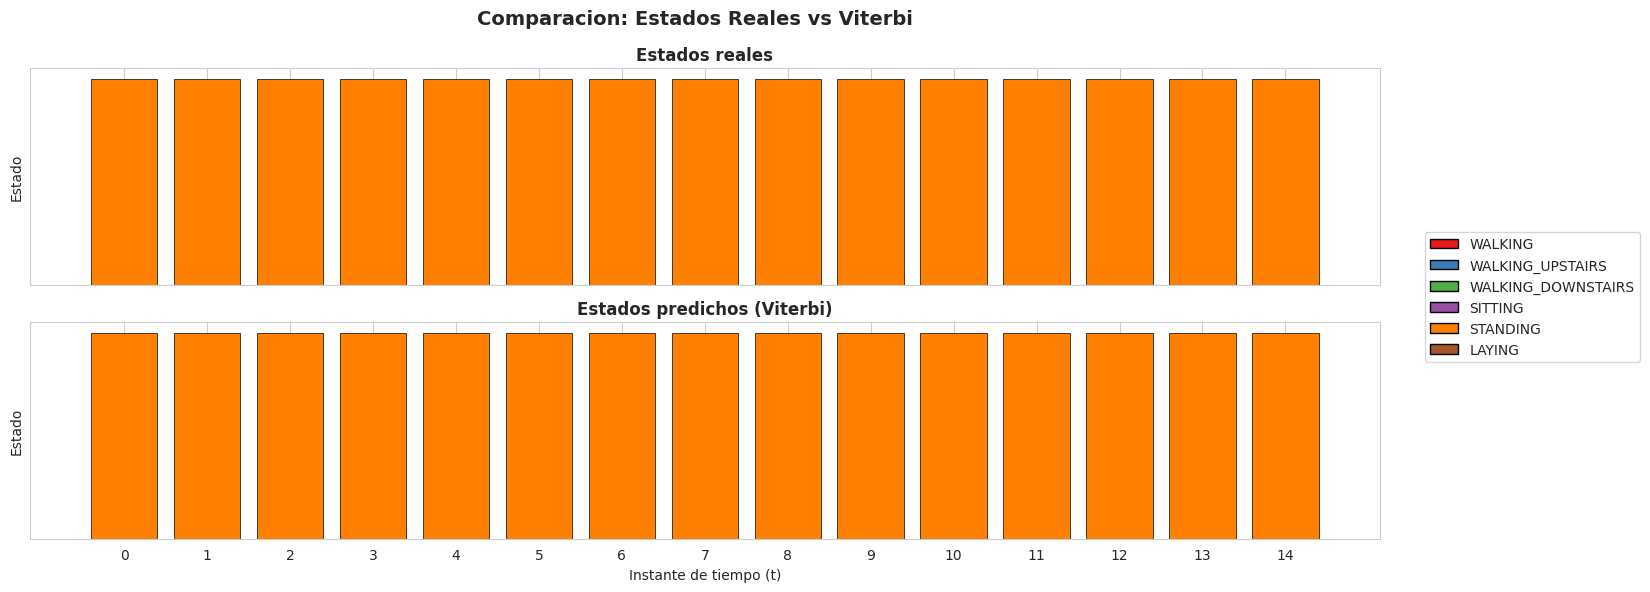

In [30]:
# ── 2.4c Visualización comparativa: Viterbi vs Real ──
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Gráfico superior: Estados reales
for t in range(seq_length):
    axes[0].bar(t, 1, color=colors_hmm[states_subseq[t]], edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Estado')
axes[0].set_title('Estados reales', fontweight='bold')
axes[0].set_yticks([])

# Gráfico inferior: Estados Viterbi
for t in range(seq_length):
    axes[1].bar(t, 1, color=colors_hmm[viterbi_states[t]], edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Estado')
axes[1].set_title('Estados predichos (Viterbi)', fontweight='bold')
axes[1].set_yticks([])
axes[1].set_xlabel('Instante de tiempo (t)')
axes[1].set_xticks(range(seq_length))

# Leyenda
legend_elements = [Patch(facecolor=colors_hmm[i], edgecolor='black',
                         label=activity_map[i+1]) for i in range(n_states)]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.18, 0.5))

plt.suptitle('Comparacion: Estados Reales vs Viterbi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Análisis e interpretación de resultados (Parte 2)

### Definición de estados y observaciones
- Los 6 estados del HMM corresponden directamente a las actividades del dataset HAR.
- Se utilizaron 2 índices (magnitud de aceleración corporal y magnitud de giroscopio corporal) discretizados por terciles para generar 9 observaciones posibles.
- La discretización por terciles es adecuada porque genera bins equilibrados y no requiere suposiciones sobre la distribución de los datos.

### Matriz de transición
- La diagonal de la matriz A muestra valores altos, lo que indica que las actividades tienden a **persistir en el tiempo** (alta probabilidad de permanecer en el mismo estado). Esto es coherente con la naturaleza de las actividades: una persona que camina tiende a seguir caminando.
- Las transiciones entre actividades dinámicas (WALKING, WALKING_UP, WALKING_DOWN) son más frecuentes entre sí que con actividades estáticas.
- Las actividades estáticas (SITTING, STANDING, LAYING) también tienden a transicionar entre ellas.

### Matriz de emisión
- Las actividades dinámicas (caminar, subir/bajar escaleras) tienden a generar observaciones con **alta magnitud de aceleración**, mientras que las estáticas (sentado, de pie) generan observaciones con **baja magnitud**.
- LAYING tiene un patrón de emisión particular debido a la orientación del sensor (la gravedad afecta diferente al estar acostado).

### Forward-Backward
- Las probabilidades a posteriori muestran que el modelo logra identificar con razonable certeza el estado en cada instante.
- En instantes donde la observación es ambigua, la probabilidad se distribuye entre varios estados posibles.

### Viterbi
- La secuencia de Viterbi tiende a ser coherente temporalmente (evita saltos rápidos entre estados) porque considera la secuencia completa de forma global.
- La precisión del modelo depende de la calidad de la discretización: al reducir 561 features a 2 índices y 9 observaciones, se pierde información discriminativa.
- La probabilidad del camino Viterbi como fracción de la probabilidad total indica cuánta masa de probabilidad concentra el camino más probable.

### Limitaciones
- La discretización a solo 9 observaciones pierde mucha información de los 561 features originales.
- El modelo HMM asume independencia condicional de las observaciones dado el estado, lo cual puede no ser completamente válido.
- La suposición de Markov (el futuro solo depende del presente) puede ser limitante para actividades con dependencia temporal más larga.

---
**Fin de la Tarea 1.**